images/trial/20250709125004210_2.bmp


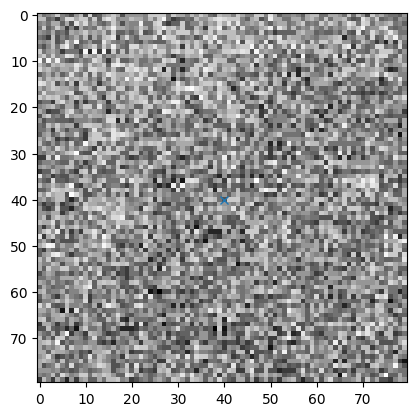

images/trial/20250714121851932_0.bmp


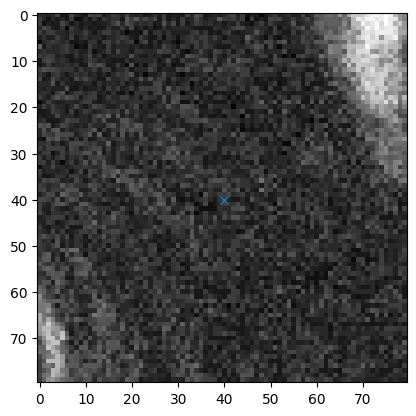

7.856881525342714


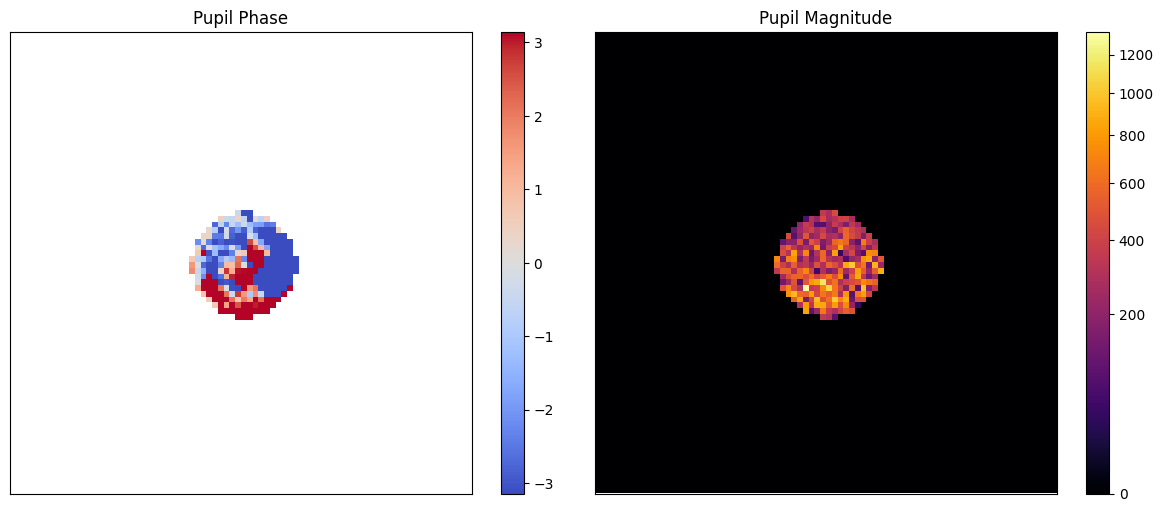

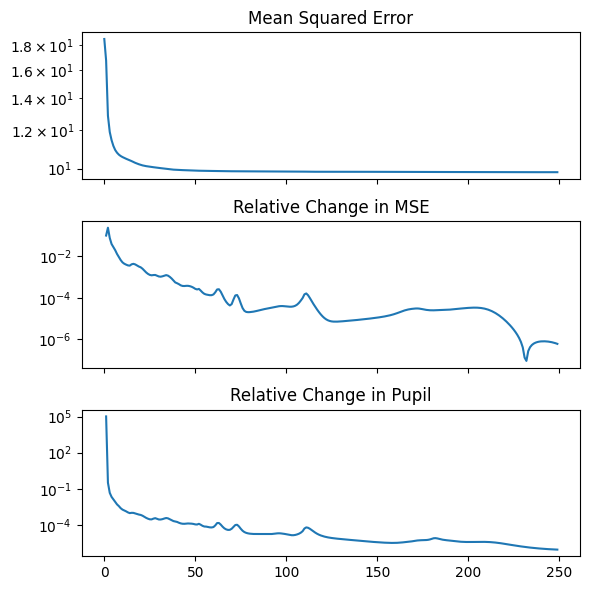

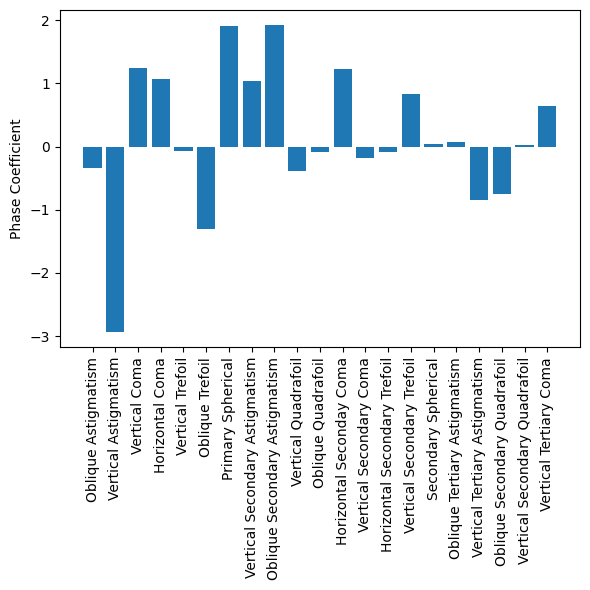

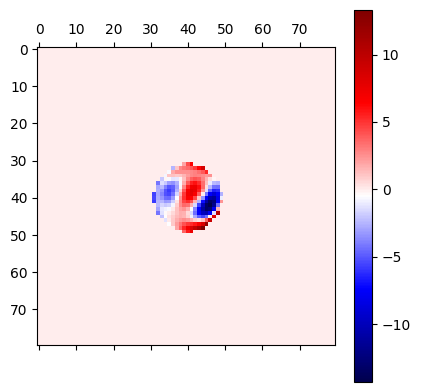

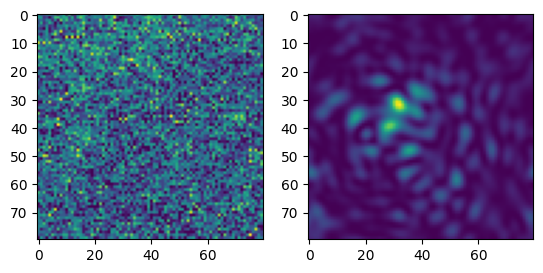

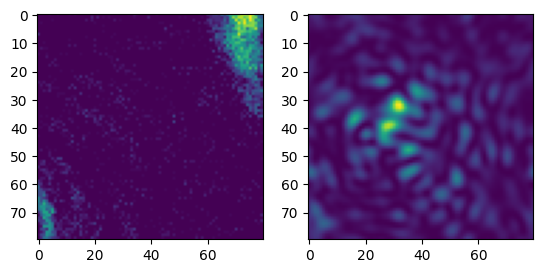

: 

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np


x0 = 939

y0 = 1668

 

 

directory = os.fsencode("images/trial/")

stack = []

for i,file in enumerate(sorted(os.listdir(directory))):


    filename = os.fsdecode(directory+file)

    print(filename)

    im = np.array(Image.open(filename))
    
    im = im[400:2600,:3000] 

    xshift = int(0*i)

    yshift = int(0*i)

    p = np.array(im)[x0-40+yshift:x0+40+yshift,y0-40+xshift:y0+40+xshift]

    plt.plot([40,], [40,],'x')

    stack.append(p)

    plt.imshow(p, cmap = 'Greys_r')

    plt.show()

stack = np.array(stack[:])

 

test_data =stack

 

#from pyotf import HanserPSF

from pyotf.phaseretrieval import *

from pyotf.utils import *

 

params = dict(

    size=test_data.shape[-1],

    zsize=test_data.shape[0],

    na=0.4,

    res=114  ,

    zres=100000/150*1,

    wl=399,

    ni=1.0,

    vec_corr="none",

    condition="none",

)

 

params["size"] = 512

junk = prep_data_for_PR(test_data, None, 1.05)

 

result = retrieve_phase(junk, params, 250, pupil_tol=np.nan, mse_tol=np.nan, phase_only=False)

result.plot()

result.plot_convergence()

zd_result = result.fit_to_zernikes(25)

zd_result.plot_named_coefs()

 

plt.matshow(zd_result.phase(slice(4, None, None)), cmap="seismic")

plt.colorbar()

print(result.rms_error)

plt.figure()

psf = result.generate_zd_psf()

for im,sim in zip(junk,psf):

    plt.subplot(1,2,1)

    plt.imshow(im)

   

    plt.subplot(1,2,2)

    plt.imshow(sim)

   

    

    plt.show()